# 🚀 **SAIR GPT from Scratch — Lecture 1: Forging Your AI's Language Brain**  
## *"Where Raw Text Becomes Model Food - Let the Feast Begin!"*  

**Course:** GPT from Scratch &nbsp;|&nbsp; **Instructor:** Mohammed Awad Ahmed (Silva) &nbsp;|&nbsp; **SAIR Community:** Building Sudan's AI Future 🇸🇩

<div align="center">
  <img src="https://media.giphy.com/media/LmNwrBhejkK9EFP504/giphy.gif" width="200" alt="Robot chef cooking data">
</div>  

**Welcome to the first forge of your AI smithing journey!** 🔨  
This isn't just data prep - it's **alchemy** turning messy human text into pure machine gold.  

---

## 🌌 **Your LLM-Building Odyssey Begins With...**

```python
# 0. [✅] Install coffee ☕               # Mandatory dev tool!
# 1. [🔥] Text Ingestion                 # Devour the Wizarding World 📚
# 2. [🔡] Tokenization Magic             # Words → Machine DNA
# 3. [📦] Data Packaging                 # GPU-friendly snack packs
# 4. [🏎️] Turbo DataLoader               # Your model's food conveyor
```

---

## 🧙 **Tokenization Wizardry - Watch This Spell!**

```diff
+ Human Verse:
  "It does not do to dwell on dreams and forget to live." 📖

+ GPT-2 Tokenization Alchemy:
  [1026, 857, 407, 466, 284, 17387, 319, 10173, 290, 6044, 284, 2107, 13]
```

**Why Care?**  
Bad tokenization = Your model speaks like Dobby on a bad day 🧦  

---

## 🏗️ **Data Pipeline Blueprint**  

<div align="center">
  <pre>
  Raw Text          → Token Stream       → Sliding Windows        → Lightning Batches
  (Harry's 📚)     (Numbers🔢)          (Overlapping Context🪟)         (GPU Food⚡)
  </pre>
</div>

---

## ⚙️ **Under the Hood: Critical Choices**  

| Component        | Superpower 💪                | Why It Matters 🧠                |
|------------------|-----------------------------|----------------------------------|
| `stride=128`     | Sliding Window Magic 🪟     | 4x More Training Examples!       |
| `max_length=512` | Context Limiter 🛑          | Fits GPU Memory + Matches GPT-2  |
| `.bin Format`    | Speed Demon 🏎️              | Loads 100x Faster Than CSV 🐌    |

---

## 🎯 **Your First Victory Lap**  

```bash
# After running this notebook, you'll have:
data/
├── train_ids.bin  # 90% of the wizarding world
├── val_ids.bin    # 7% for validation
└── test_ids.bin   # 3% for final testing
```

**Plus:** A DataLoader serving batches like a Michelin-star chef 🧑‍🍳  

---

## 🌠 **What's Next? Sneak Peek!**  

```diff
+ Coming in Notebook 2: 
! 🤖 Birth Your Transformer - Sparks fly as we initialize layers!
! ⚡ Attention is All You Need - Teach your AI to focus like a monk
! 🔥 Loss Function Showdown - "Why is my model speaking gibberish?"
```

---

  <h3>Ready to transform data dust into AI gold? Let's make history! 🏆</h3>
</div>

# Required Packages

Everything we need is already in the SAIR environment:

- `torch` — tensor operations and the DataLoader
- `tiktoken` — production-grade BPE tokenizer (same one used in GPT-2/GPT-4)
- `numpy`, `matplotlib` — data handling and visualization
- Standard library only for data loading — no HuggingFace required 🎉


In [ ]:
# !pip install tiktoken torch

## 📖 Step 1 — Loading the Data

We're using the **Harry Potter book series** (all 7 books) as our training corpus. You already saw this data in Module 4 where you trained RNNs and LSTMs on it — now you'll train a GPT on the same text. Good benchmark for comparison.

The books live locally in the SAIR repo, so no downloads or API calls needed. We load them with plain Python `open()` and join them into one continuous string.

In [22]:
import os
import glob

# Path to Harry Potter books (already in the SAIR repo from Module 4)
BOOKS_DIR = '../4_Applied Deep Learning with PyTorch/3_Sequence and NLP/harry_potter_txt/'

book_files = sorted(glob.glob(os.path.join(BOOKS_DIR, '*.txt')))

texts = []
for path in book_files:
    with open(path, 'r', encoding='utf-8') as f:
        texts.append(f.read())

print(f'Loaded {len(texts)} books:')
for path, text in zip(book_files, texts):
    print(f'  {os.path.basename(path):50s}  {len(text):>10,} chars')

# Combine into one continuous corpus
full_text = '\n\n'.join(texts)
print(f'\nTotal corpus size: {len(full_text):,} characters')


Loaded 7 books:
  Book 1 - The Philosopher's Stone.txt                   474,429 chars
  Book 2 - The Chamber of Secrets.txt                    531,708 chars
  Book 3 - The Prisoner of Azkaban.txt                   676,978 chars
  Book 4 - The Goblet of Fire.txt                      1,187,250 chars
  Book 5 - The Order of the Phoenix.txt                1,608,763 chars
  Book 6 - The Half Blood Prince.txt                   1,059,022 chars
  Book 7 - The Deathly Hallows.txt                     1,227,024 chars

Total corpus size: 6,765,186 characters


## ✂️ Step 2 — Splitting into Train / Val / Test

We split the corpus into three sets:

| Split | Size | Purpose |
|-------|------|---------|
| **Train** | 90% | The model learns from this |
| **Val** | 7% | We check loss during training to detect overfitting |
| **Test** | 3% | Final honest evaluation after training is done |

We split by **character position** on the raw text — simple and clean. No shuffling: keeping the books in order preserves narrative flow, which matters for a language model.

In [23]:
import numpy as np

# Split percentages
train_percentage      = 0.90
validation_percentage = 0.07
test_percentage       = 0.03

n = len(full_text)
train_end = int(n * train_percentage)
val_end   = int(n * (train_percentage + validation_percentage))

train_text = full_text[:train_end]
val_text   = full_text[train_end:val_end]
test_text  = full_text[val_end:]

print(f'Train :  {len(train_text):>10,} chars')
print(f'Val   :  {len(val_text):>10,} chars')
print(f'Test  :  {len(test_text):>10,} chars')


Train :   6,088,667 chars
Val   :     473,563 chars
Test  :     202,956 chars


In [24]:
# Quick look at what we're working with
print('=== First 500 characters of the corpus ===\n')
print(full_text[:500])
print('\n...')
print('\n=== Sample from the middle ===')
mid = len(full_text) // 2
print(full_text[mid:mid+300])


=== First 500 characters of the corpus ===

/ 




THE BOY WHO LIVED 

Mr. and Mrs. Dursley, of number four, Privet Drive, 
were proud to say that they were perfectly normal, 
thank you very much. They were the last people you’d 
expect to be involved in anything strange or 
mysterious, because they just didn’t hold with such 
nonsense. 

Mr. Dursley was the director of a firm called 
Grunnings, which made drills. He was a big, beefy 
man with hardly any neck, although he did have a 
very large mustache. Mrs. Dursley was thin and 
blonde 

...

=== Sample from the middle ===
learly just returned from hunting. The straw- 
covered floor crunched a little as he stepped across 
tiny animal bones, craning his neck for a sight of 
Hedwig. 

“There you are,” he said, spotting her somewhere near 
the very top of the vaulted ceiling. “Get down here, 

I’ve got a letter for you.”


=== Dataset Overview ===
Number of books   : 7
Total characters  : 6,765,186
Total words (est) : 1,168,853
Unique characters : 92

=== Per-book breakdown ===
  Book 1 - The Philosopher's Stone.txt                  83,188 words     474,429 chars
  Book 2 - The Chamber of Secrets.txt                   92,168 words     531,708 chars
  Book 3 - The Prisoner of Azkaban.txt                 116,621 words     676,978 chars
  Book 4 - The Goblet of Fire.txt                      206,157 words   1,187,250 chars
  Book 5 - The Order of the Phoenix.txt                276,563 words   1,608,763 chars
  Book 6 - The Half Blood Prince.txt                   182,361 words   1,059,022 chars
  Book 7 - The Deathly Hallows.txt                     211,795 words   1,227,024 chars


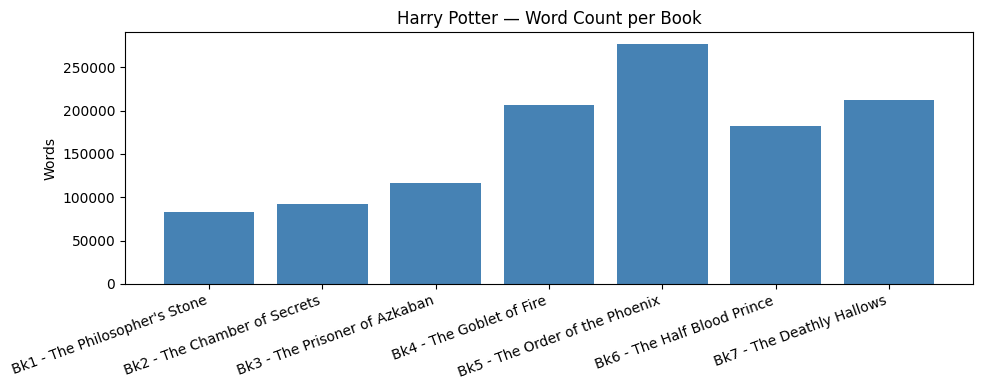

In [26]:
# Exploratory Data Analysis on the Harry Potter corpus

print('=== Dataset Overview ===')
print(f'Number of books   : {len(texts)}')
print(f'Total characters  : {len(full_text):,}')
print(f'Total words (est) : {len(full_text.split()):,}')
print(f'Unique characters : {len(set(full_text)):,}')

print('\n=== Per-book breakdown ===')
for path, text in zip(book_files, texts):
    name = os.path.basename(path)
    words = len(text.split())
    print(f'  {name:50s}  {words:>8,} words  {len(text):>10,} chars')

import matplotlib.pyplot as plt
book_names = [os.path.basename(p).replace('.txt','').replace('Book ','Bk') for p in book_files]
word_counts = [len(t.split()) for t in texts]
plt.figure(figsize=(10, 4))
plt.bar(book_names, word_counts, color='steelblue')
plt.title('Harry Potter — Word Count per Book')
plt.ylabel('Words')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


# Designing a Simple Tokenizer

Designing a simple tokenizer is a crucial step in preparing your text data for training a language model. Tokenization involves breaking down the text into smaller units, or tokens, that can be processed by the model. While there are many efficient tokenization libraries available, like **Tiktoken**, it's essential to understand the underlying functionality of tokenization to appreciate how these tools work and to make informed choices when selecting or designing a tokenizer.

## Building a Simple Tokenizer

Here’s a step-by-step guide to creating a simple tokenizer using Python:

### 1. Define Tokenizer Class:
- Create a class that handles both tokenization and detokenization.
- This tokenizer will use a basic approach to split text into words and maintain a vocabulary.

### 2. Tokenization Process:
- **Convert Text into Tokens:** Break the text into smaller units, typically words, but you may also consider subword units for more complex models.
- **Create a Mapping:** Develop a mapping from tokens to their corresponding indices (vocabulary). This is crucial for converting text into a numerical format that can be fed into machine learning models.

### 3. Detokenization Process:
- **Convert Indices Back into Words:** Implement a mechanism to reconstruct the original text from the indices using the inverse mapping. This is important for interpreting model outputs and debugging.



In [27]:
# lets peform some text preprocessing to be add later to the tokinizer function class

import re  # Importing the regular expressions module for text processing

# Sample text containing words, spaces, and punctuation
sample_text = "hello my name is is Mohammed , and Im a deep learning engineer"

# Split the sample text by whitespace while retaining the whitespace as separate elements
output1 = re.split(r'(\s)', sample_text)

# Split the sample text by spaces and punctuation (commas and periods), retaining the delimiters
output2 = re.split(r'([,.]|\s)', sample_text)

# Remove any empty strings from the output list. This is done to clean up the results.
output3 = [item for item in output2 if item.strip()]        

# Print the outputs to see the results of each split operation
print("Output 1 (split by whitespace):")
print(output1)  # Displays the text split into words with whitespace included
print("\nOutput 2 (split by spaces and punctuation):")
print(output2)  # Displays the text split into words and includes punctuation as separate elements
print("\nOutput 3 (cleaned output):")
print(output3)  # Displays the cleaned list without empty strings


Output 1 (split by whitespace):
['hello', ' ', 'my', ' ', 'name', ' ', 'is', ' ', 'is', ' ', 'Mohammed', ' ', ',', ' ', 'and', ' ', 'Im', ' ', 'a', ' ', 'deep', ' ', 'learning', ' ', 'engineer']

Output 2 (split by spaces and punctuation):
['hello', ' ', 'my', ' ', 'name', ' ', 'is', ' ', 'is', ' ', 'Mohammed', ' ', '', ',', '', ' ', 'and', ' ', 'Im', ' ', 'a', ' ', 'deep', ' ', 'learning', ' ', 'engineer']

Output 3 (cleaned output):
['hello', 'my', 'name', 'is', 'is', 'Mohammed', ',', 'and', 'Im', 'a', 'deep', 'learning', 'engineer']


In [28]:
# Text Preprocessing with Regular Expressions
# In this example, we will preprocess a sample text string using Python's re module.
# We will split the text into meaningful tokens, including punctuation and words, and then clean the result.

import re  # Import the regular expressions module for text processing

# Sample text containing words, spaces, and various punctuation marks
sample_text2 = "Hi ! , my name is Mohammed , do you like som tea ? ---- or no?"

# Split the sample text by specific punctuation marks and whitespace
# The regex pattern includes various punctuation characters and handles the double hyphen (--)
preprcessed_text = re.split(r'([,.:;!_?"()\']|--|\s)', sample_text2)

# Remove any empty strings from the output list to clean up the results
preprcessed_text = [item for item in preprcessed_text if item.strip()]

# Print the preprocessed text to see the tokens generated
print(preprcessed_text)  # Displays the list of tokens from the sample text

# Get the number of tokens generated after preprocessing
num_tokens = len(preprcessed_text)
print(f"Number of tokens: {num_tokens}")  # Displays the total count of tokens


['Hi', '!', ',', 'my', 'name', 'is', 'Mohammed', ',', 'do', 'you', 'like', 'som', 'tea', '?', '--', '--', 'or', 'no', '?']
Number of tokens: 19


In [29]:
# Apply preprocessing to the full corpus split into passages (one per 1000 chars for demo)
# In practice the tokenizer classes below consume the raw text directly

def preprcessed_text(text):
    import re
    tokens = re.split(r'([,.:;!_?"()\']|--|\s)', text)
    return [item for item in tokens if item.strip()]

# Build preprocessed list from train split (chunked so it fits in memory comfortably)
chunk_size = 2000
train_chunks = [train_text[i:i+chunk_size] for i in range(0, len(train_text), chunk_size)]
preprcessed_dataset = {'train': [preprcessed_text(c) for c in train_chunks]}

print(f'Chunks: {len(preprcessed_dataset["train"])}')
print(f'Tokens in first chunk: {len(preprcessed_dataset["train"][0])}')
print(f'Sample: {preprcessed_dataset["train"][0][:20]}')


Chunks: 3045
Tokens in first chunk: 400
Sample: ['/', 'THE', 'BOY', 'WHO', 'LIVED', 'Mr', '.', 'and', 'Mrs', '.', 'Dursley', ',', 'of', 'number', 'four', ',', 'Privet', 'Drive', ',', 'were']


In [30]:
# First, we extract unique tokens from the preprocessed dataset's first training entry.
# This will help us build a vocabulary that can be used for tokenization.
all_words = sorted(set(preprcessed_dataset['train'][0]))

# Calculate the vocabulary size, which is the number of unique tokens we found.
vocab_size  = len(all_words)

# Print the vocabulary size to understand how many unique tokens we will work with.
print(vocab_size)  # Fixed typo: 'ptint' changed to 'print'

# Create a vocabulary dictionary where each token is mapped to a unique integer.
# This mapping is essential for converting text into a format that can be processed by the model.
vocab = {token: integer for integer, token in enumerate(all_words)}

# Iterate through the vocabulary to display each token and its corresponding index.
for i, item in enumerate(all_words):
    print(item)  # Print each token from the vocabulary


206
,
-
.
/
2
;
BOY
Drive
Dudley
Dursley
Dursleys
Dursley’s
Grunnings
Harry
He
J
K
LIVED
Mr
Mrs
None
Page
Philosophers
Potter
Potters
Privet
Rowling
Stone
THE
The
They
This
Tuesday
WHO
When
a
about
all
also
although
amount
and
another
any
anyone
anything
anywhere
arrived
as
away
be
bear
because
beefy
big
blonde
boring
boy
but
called
came
chair
child
cloudy
could
country
craning
did
didn’t
director
discover
drills
dull
even
everything
expect
fact
fear
fences
finer
firm
for
found
four
garden
good
good-for-nothing
gossiped
gray
greatest
had
hadn’t
happening
happily
hardly
have
he
her
high
him
his
hold
hummed
husband
if
in
into
involved
it
just
keeping
knew
large
last
like
made
man
met
mixing
most
much
mustache
mysterious
n
nearly
neck
neighbors
never
no
nonsense
normal
nothing
number
of
on
opinion
or
our
out
outside
over
people
perfectly
picked
possible
pretended
proud
reason
s
say
screaming
secret
seen
several
she
shuddered
sister
sky
small
so
somebody
son
soon
spent
spying
starts
story


In [31]:
import re

class TokenizerV1:
    def __init__(self, dataset):
        # Initialize the Tokenizer with a dataset
        
        # Preprocess the dataset text once and store it for future use
        self.preprocessed_dataset = [
            self.preprocessed_text(text) for text in dataset
        ]
        
        # Create a sorted set of all unique tokens from the preprocessed dataset
        self.all_words = sorted(set(
            token for tokens in self.preprocessed_dataset for token in tokens
        ))
        
        # Create a vocabulary mapping tokens to unique integer indices
        self.vocab = {token: integer for integer, token in enumerate(self.all_words)}
        
        # Create a reverse mapping from integer indices back to tokens
        self.int_to_str = {integer: token for token, integer in self.vocab.items()}

    def preprocessed_text(self, text):
        """
        Preprocesses the input text by splitting it into tokens based on 
        specified punctuation marks and whitespace.
        
        Args:
            text (str): The input text to preprocess.
        
        Returns:
            List[str]: A list of preprocessed tokens.
        """
        # Split the sample text by specific punctuation marks and whitespace
        preprocessed_text = re.split(r'([,.:;!_?"()\']|--|\s)', text)
        
        # Remove any empty strings from the output list to clean up the results
        preprocessed_text = [item for item in preprocessed_text if item.strip()]
        return preprocessed_text

    def encode(self, text):
        """
        Encodes the input text into a sequence of integer IDs based on the vocabulary.
        
        Args:
            text (str): The input text to encode.
        
        Returns:
            List[int]: A list of integer IDs corresponding to the tokens in the input text.
        """
        # Preprocess the text into tokens
        preprocessed_tokens = self.preprocessed_text(text)
        
        # Debugging output to display the preprocessed tokens
        print("Preprocessed Tokens:", preprocessed_tokens)  
        
        # Map each token to its corresponding integer ID
        ids = [self.vocab[token] for token in preprocessed_tokens if token in self.vocab]
        
        return ids

    def decode(self, ids):
        """
        Decodes a sequence of integer IDs back into human-readable text.
        
        Args:
            ids (List[int]): A list of integer IDs to decode.
        
        Returns:
            str: The reconstructed text from the list of integer IDs.
        """
        # Join the integer IDs back to their corresponding tokens
        text = " ".join([self.int_to_str[i] for i in ids if i in self.int_to_str])
        
        # Clean up the reconstructed text by removing extra spaces before punctuation
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        
        return text


In [32]:
# Build vocabulary from a sample of training text (first 50 chunks)
sample_chunks = train_chunks[:50]
tok = TokenizerV1(sample_chunks)

text = "It does not do to dwell on dreams and forget to live."
ids = tok.encode(text)
print('Encoded IDs :', ids)
print('Decoded Text:', tok.decode(ids))


Preprocessed Tokens: ['It', 'does', 'not', 'do', 'to', 'dwell', 'on', 'dreams', 'and', 'forget', 'to', 'live', '.']
Encoded IDs : [269, 1061, 1886, 1059, 2694, 1910, 584, 2694, 1686, 8]
Decoded Text: It does not do to on and to live.


One small thing but important. The <UNK> token is used to represent unknown words in the text.
so with that in mind lets update the TokenizerV1 class to TokenizerV2 to handle this probelm 

In [12]:
class TokenizerV2:
    def __init__(self, dataset):
        # Initialize the Tokenizer with a dataset
        
        # Preprocess the dataset text once and store it for future use
        self.preprocessed_dataset = [
            self.preprocessed_text(text) for text in dataset
        ]
        
        # Create a sorted set of all unique tokens from the preprocessed dataset
        self.all_words = sorted(set(
            token for tokens in self.preprocessed_dataset for token in tokens
        ))
        
        # Add a special <UNK> token for unknown words
        self.all_words.append('<UNK>')
        
        # Create a vocabulary mapping tokens to unique integer indices
        self.vocab = {token: integer for integer, token in enumerate(self.all_words)}
        
        # Create a reverse mapping from integer indices back to tokens
        self.int_to_str = {integer: token for token, integer in self.vocab.items()}
        
        # Save the ID for the <UNK> token
        self.unk_token_id = self.vocab['<UNK>']

    def preprocessed_text(self, text):
        """
        Preprocesses the input text by splitting it into tokens based on 
        specified punctuation marks and whitespace.
        
        Args:
            text (str): The input text to preprocess.
        
        Returns:
            List[str]: A list of preprocessed tokens.
        """
        # Split the sample text by specific punctuation marks and whitespace
        preprocessed_text = re.split(r'([,.:;!_?"()\']|--|\s)', text)
        
        # Remove any empty strings from the output list to clean up the results
        preprocessed_text = [item for item in preprocessed_text if item.strip()]
        return preprocessed_text

    def encode(self, text):
        """
        Encodes the input text into a sequence of integer IDs based on the vocabulary.
        
        Args:
            text (str): The input text to encode.
        
        Returns:
            List[int]: A list of integer IDs corresponding to the tokens in the input text.
        """
        # Preprocess the text into tokens
        preprocessed_tokens = self.preprocessed_text(text)
        
        # Debugging output to display the preprocessed tokens
        print("Preprocessed Tokens:", preprocessed_tokens)
        
        # Map each token to its corresponding integer ID, or to <UNK> if the token is not found
        ids = [self.vocab.get(token, self.unk_token_id) for token in preprocessed_tokens]
        
        return ids

    def decode(self, ids):
        """
        Decodes a sequence of integer IDs back into human-readable text.
        
        Args:
            ids (List[int]): A list of integer IDs to decode.
        
        Returns:
            str: The reconstructed text from the list of integer IDs.
        """
        # Join the integer IDs back to their corresponding tokens
        text = " ".join([self.int_to_str[i] for i in ids if i in self.int_to_str])
        
        # Clean up the reconstructed text by removing extra spaces before punctuation
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        
        return text

# Example usage
dataset = {
    'train': {
        'text': [
            "Hello, world! How are you?",
            "This is a test sentence.",
            "Tokenizer test!"
        ]
    }
}

# Initialize TokenizerV2
tok = TokenizerV2(dataset)

# Example text with unknown words
text = """Hello, unknown_token! This should map to <UNK>."""
ids = tok.encode(text)
print("Encoded IDs:", ids)
print("Decoded Text:", tok.decode(ids))


Preprocessed Tokens: ['Hello', ',', 'unknown', '_', 'token', '!', 'This', 'should', 'map', 'to', '<UNK>', '.']
Encoded IDs: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Decoded Text: <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>


## From Building a Tokenizer to Using `tiktoken` for Efficiency

We had some fun implementing a simple tokenizer from scratch, which gave us valuable insights into the fundamental workings of tokenization—splitting text into tokens, mapping tokens to integers, and even handling unknown tokens. This hands-on approach was a great learning exercise to understand what happens under the hood when text is processed for NLP tasks.

However, in real-world applications, especially with large-scale models like GPT, **efficiency is crucial**. We need a tokenizer that not only handles the complexities of natural language but does so at high speed and with minimal memory overhead. That's where the **`tiktoken`** library comes in.

`tiktoken` is a highly optimized and efficient library, specifically designed for tokenizing text for large transformer models like GPT-3 and GPT-4. It uses **Byte-Pair Encoding (BPE)** to compress text, reducing the number of tokens while maintaining meaning. By leveraging `tiktoken`, we get a robust solution that can handle all edge cases—from special characters and emojis to multilingual text—while ensuring compatibility with cutting-edge language models.

Now that we understand the foundational ideas behind tokenization, it's time to implement a more efficient solution using `tiktoken`. This will give us the speed and scalability we need for real-world NLP applications, without compromising on our deeper understanding of how tokenization works.


In [13]:
#! pip install tiktoken

In [33]:
import tiktoken

sample_text = "It does not do to dwell on dreams and forget to live."

tokenizer = tiktoken.get_encoding('gpt2')

tokens = tokenizer.encode(sample_text)
decoded_text = tokenizer.decode(tokens)

print('Original Text:', sample_text)
print('Token IDs    :', tokens)
print('Decoded Text :', decoded_text)
print(f'Token count  : {len(tokens)}')


Original Text: It does not do to dwell on dreams and forget to live.
Token IDs    : [1026, 857, 407, 466, 284, 14046, 319, 10625, 290, 6044, 284, 2107, 13]
Decoded Text : It does not do to dwell on dreams and forget to live.
Token count  : 13


In [34]:
import os
import numpy as np
import tiktoken

data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)

tokenizer = tiktoken.encoding_for_model('gpt2')

def tokenize_text(text):
    """Tokenize a single string and return a numpy array of int32 token IDs."""
    return np.array(tokenizer.encode(text), dtype=np.int32)

# Tokenize each split
print('Tokenizing splits...')
train_ids = tokenize_text(train_text)
val_ids   = tokenize_text(val_text)
test_ids  = tokenize_text(test_text)

print(f'  train tokens : {len(train_ids):,}')
print(f'  val tokens   : {len(val_ids):,}')
print(f'  test tokens  : {len(test_ids):,}')

# Save as binary files (fast load, compact storage)
train_ids.tofile(os.path.join(data_dir, 'train_ids.bin'))
val_ids.tofile(os.path.join(data_dir, 'val_ids.bin'))
test_ids.tofile(os.path.join(data_dir, 'test_ids.bin'))

print('\nSaved to data/ directory:')
for fname in ['train_ids.bin', 'val_ids.bin', 'test_ids.bin']:
    size = os.path.getsize(os.path.join(data_dir, fname))
    print(f'  {fname:20s}  {size/1024:.1f} KB')


Tokenizing splits...
  train tokens : 1,891,044
  val tokens   : 147,994
  test tokens  : 61,352

Saved to data/ directory:
  train_ids.bin         7386.9 KB
  val_ids.bin           578.1 KB
  test_ids.bin          239.7 KB


Now that the data is preprocessed, tokenized, and saved, it's time to move on to the final — and arguably the most important — part of this notebook:

# **THE DATA LOADER**

This is where all the magic happens! The data loader will efficiently feed batches of text to our model, ensuring seamless training and unlocking the full potential of our language model. Let's dive into it!


### Efficient Data Loading for LLM Training: Sliding Window Algorithm

In language model training, especially for text generation, the **sliding window** algorithm is essential. It generates input-output pairs that help the model predict the next token in a sequence, crucial for text generation tasks.

#### Importance of the Sliding Window
- It extracts fixed-length input sequences (windows) from data.
- It predicts the next token that follows each window.

This process allows the model to:
1. Learn relationships between tokens within a context.
2. Maximize training data by creating multiple input-output pairs from one text sequence.

---

### Sliding Window Concept

Given a sequence, the sliding window moves across it, extracting fixed-sized chunks (e.g., 4 tokens) as inputs, and uses the token that follows the window as the target. 

#### Example Process:
- **Inputs**: Sequences of tokens (e.g., `[1, 2, 3, 4]`).
- **Target**: The next token in the sequence (e.g., `5`).
  
For each window, the model learns to predict the following token, allowing it to generate text based on context.

---

### Why It Matters for Text Generation in LLMs
- The model learns to predict the next token by observing overlapping sequences of text.
- By training on these input-output pairs, the model can generate coherent text during inference.

Understanding this sliding window mechanism is key to preparing data efficiently for training large language models.


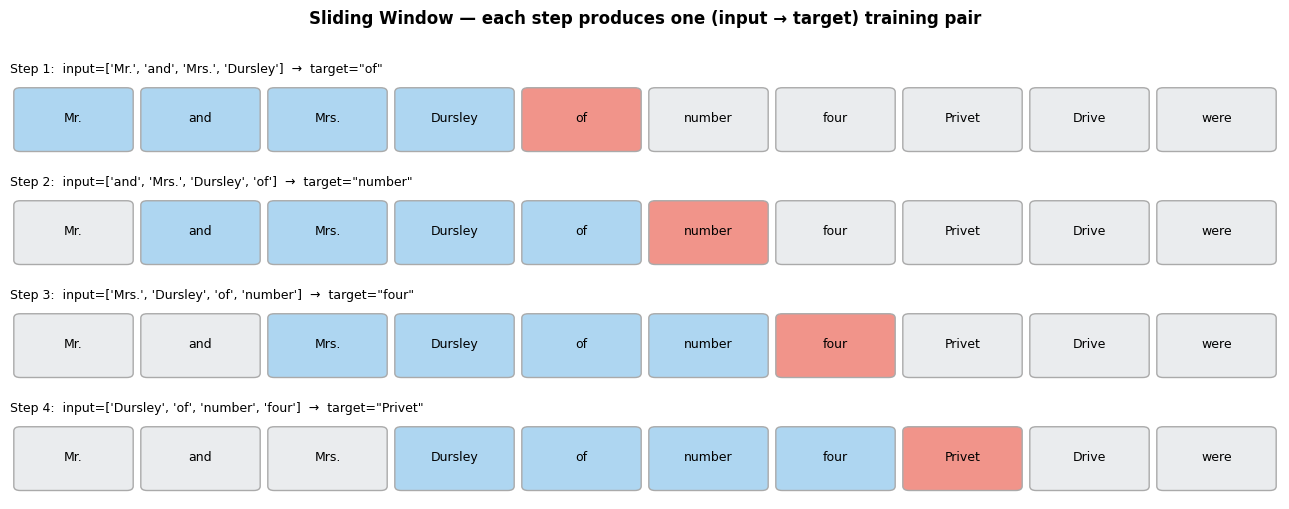

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Visualise the sliding window with real HP tokens
sample_tokens = ['Mr.', 'and', 'Mrs.', 'Dursley', 'of', 'number', 'four', 'Privet', 'Drive', 'were']
window_size = 4
n_steps = 4

fig, axes = plt.subplots(n_steps, 1, figsize=(13, 5))
fig.suptitle('Sliding Window — each step produces one (input → target) training pair',
             fontsize=12, fontweight='bold', y=1.01)

for step, ax in enumerate(axes):
    ax.set_xlim(-0.5, len(sample_tokens) - 0.5)
    ax.set_ylim(0, 1)
    ax.axis('off')
    for j, tok in enumerate(sample_tokens):
        if j >= step and j < step + window_size:
            colour = '#AED6F1'   # input window — blue
        elif j == step + window_size:
            colour = '#F1948A'   # target token — red
        else:
            colour = '#EAECEE'   # unused — grey
        rect = mpatches.FancyBboxPatch(
            (j - 0.42, 0.15), 0.84, 0.65,
            boxstyle='round,pad=0.05', facecolor=colour, edgecolor='#AAA')
        ax.add_patch(rect)
        ax.text(j, 0.5, tok, ha='center', va='center', fontsize=9)
    inp = sample_tokens[step : step + window_size]
    tgt = sample_tokens[step + window_size]
    ax.set_title(f'Step {step+1}:  input={inp}  →  target="{tgt}"',
                 fontsize=9, loc='left', pad=2)

plt.tight_layout()
plt.show()


In [36]:
# To create an efficient data loader for LLM training, we need to understand the sliding window algorithm.
# This is crucial for text generation tasks, where the model learns to predict the next token in a sequence.
# The sliding window extracts a fixed-size input window and the next token (target) for model training.

# Mock data simulating a sequence (could be a sequence of token IDs in actual text data)
mock_data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Define the size of the sliding window (number of tokens/values the model will use as input)
window_size = 4

# Initialize lists to store input windows and their corresponding target values
inputs = []
targets = []

# Loop over the data to create sliding windows and targets
# The loop will stop before the last few elements to ensure there is always a "next" token to predict
for i in range(len(mock_data) - window_size):
    # Input window: a sequence of 'window_size' tokens/values
    input_window = mock_data[i:i + window_size]
    
    # Target: the token that immediately follows the input window (i.e., the next token)
    target_value = mock_data[i + window_size]
    
    # Append the input window and its corresponding target to the respective lists
    inputs.append(input_window)
    targets.append(target_value)

# Print each input window and its corresponding target to visualize the sliding window process
for i in range(len(inputs)):
    print(f"Input {i + 1}: {inputs[i]} => Target: {targets[i]}")

# Print out the total number of inputs and their shapes (for inspection)
print(f"\nTotal inputs: {len(inputs)}, Input shape: {len(inputs[0])}")
# Print out the total number of targets (should match the number of inputs)
print(f"Total targets: {len(targets)}")


Input 1: [1 2 3 4] => Target: 5
Input 2: [2 3 4 5] => Target: 6
Input 3: [3 4 5 6] => Target: 7
Input 4: [4 5 6 7] => Target: 8
Input 5: [5 6 7 8] => Target: 9
Input 6: [6 7 8 9] => Target: 10

Total inputs: 6, Input shape: 4
Total targets: 6


In [37]:
# Show what the sliding window looks like on REAL Harry Potter tokens
import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')

# Take a small slice from the training data
sample_ids = np.fromfile('data/train_ids.bin', dtype=np.int32)[:20]
window_size = 4

print('Real sliding window on HP tokens\n')
print(f'{"Step":<6} {"Input tokens (IDs)":<35} {"→"} {"Target"}')
print('-' * 70)
for step in range(5):
    inp = sample_ids[step : step + window_size].tolist()
    tgt = int(sample_ids[step + window_size])
    inp_text = tokenizer.decode(inp)
    tgt_text = tokenizer.decode([tgt])
    print(f'{step+1:<6} {str(inp):<35}  →  {tgt}  ("{tgt_text.strip()}")')

print()
print('Decoded as text:')
print('-' * 70)
for step in range(5):
    inp_text = tokenizer.decode(sample_ids[step : step + window_size].tolist())
    tgt_text = tokenizer.decode([int(sample_ids[step + window_size])])
    print(f'Step {step+1}:  "{inp_text.strip()}"  →  "{tgt_text.strip()}"')


Real sliding window on HP tokens

Step   Input tokens (IDs)                  → Target
----------------------------------------------------------------------
1      [14, 220, 628, 628]                  →  198  ("")
2      [220, 628, 628, 198]                 →  10970  ("THE")
3      [628, 628, 198, 10970]               →  16494  ("BO")
4      [628, 198, 10970, 16494]             →  56  ("Y")
5      [198, 10970, 16494, 56]              →  19494  ("WHO")

Decoded as text:
----------------------------------------------------------------------
Step 1:  "/"  →  ""
Step 2:  ""  →  "THE"
Step 3:  "THE"  →  "BO"
Step 4:  "THE BO"  →  "Y"
Step 5:  "THE BOY"  →  "WHO"


## 🔧 PyTorch `Dataset` and `DataLoader`

Two classes do all the heavy lifting in PyTorch data pipelines:

**`Dataset`** — defines *how to access* your data. Three methods required:
- `__init__` — load/store the data
- `__len__` — how many samples total
- `__getitem__` — return one (input, target) pair by index

**`DataLoader`** — wraps a `Dataset` and handles:
- **Batching** — groups samples into batches of size `batch_size`
- **Shuffling** — randomises order each epoch so the model doesn't memorise sequence
- **`drop_last=True`** — drops the final incomplete batch so every batch is the same size

For an LLM, `__getitem__` returns:
- `x` — tokens at positions `[i : i + max_length]`
- `y` — tokens at positions `[i+1 : i + max_length + 1]` (shifted by one)

This one-position shift is the core of next-token prediction: given `x`, predict `y`.

In [38]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset

class GPT2Dataset(Dataset):
    def __init__(self, file_path, max_length, stride):
        """
        Initializes the dataset by reading the binary data from the given file and setting up parameters.
        
        Args:
            file_path (str): Path to the .bin file containing tokenized data.
            max_length (int): The size of the input window (sequence length).
            stride (int): The step size for sliding the window.
        """
        # Load the binary file as a NumPy array
        self.data = np.fromfile(file_path, dtype=np.int32)
        self.max_length = max_length
        self.stride = stride

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        """
        return (len(self.data) - self.max_length) // self.stride

    def __getitem__(self, idx):
        """
        Retrieves a single input-output pair by index.

        Args:
            idx (int): Index of the data.

        Returns:
            input_seq (torch.Tensor): Input sequence of length max_length.
            output_seq (torch.Tensor): Output sequence (next tokens), shifted by one.
        """
        # Calculate the start index based on the stride
        start_idx = idx * self.stride
        input_seq = self.data[start_idx: start_idx + self.max_length]
        output_seq = self.data[start_idx + 1: start_idx + self.max_length + 1]
        
        # Convert input/output to PyTorch tensors
        input_seq = torch.tensor(input_seq, dtype=torch.long)
        output_seq = torch.tensor(output_seq, dtype=torch.long)
        
        return input_seq, output_seq


In [39]:
# Define the path to the training file in the data subdirectory
train_file = 'data/train_ids.bin'

max_length = 512   # context window length
stride     = 128   # step between windows (< max_length → overlapping → more training samples)

train_dataset = GPT2Dataset(file_path=train_file, max_length=max_length, stride=stride)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

# Grab one batch and inspect
x_batch, y_batch = next(iter(train_loader))
print(f'Batch shape — inputs : {x_batch.shape}')   # [32, 512]
print(f'Batch shape — targets: {y_batch.shape}')   # [32, 512]
print(f'Total batches in loader: {len(train_loader)}')

# Decode first sample to make the input→target shift tangible
import tiktoken
enc = tiktoken.get_encoding('gpt2')
print('\n--- First sample decoded ---')
print('INPUT  :', enc.decode(x_batch[0][:12].tolist()), '...')
print('TARGET :', enc.decode(y_batch[0][:12].tolist()), '...')
print('\nNotice: TARGET is INPUT shifted one position to the right.')


Batch shape — inputs : torch.Size([32, 512])
Batch shape — targets: torch.Size([32, 512])
Total batches in loader: 461

--- First sample decoded ---
INPUT  : �It is a pity it broke,” said Hermione ...
TARGET : It is a pity it broke,” said Hermione quietly ...

Notice: TARGET is INPUT shifted one position to the right.


## Summary

We've had a lot of fun experimenting in this notebook, but everything we did boils down to three clean steps:

1. **Load the data** — read all 7 Harry Potter books from local `.txt` files, combine into one corpus, split into train / val / test
2. **Understand tokenization** — built `TokenizerV1` and `TokenizerV2` from scratch, then switched to `tiktoken` for production-grade BPE tokenization
3. **Build an efficient DataLoader** — implemented the sliding window algorithm to generate input/target pairs, wrapped in a PyTorch `Dataset` and `DataLoader`

No HuggingFace. No Keras. Just Python, NumPy, and PyTorch. 💪


In [ ]:
# DATA.py  — production-ready version of everything in this notebook
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import tiktoken

# ── 1. Load ────────────────────────────────────────────────────────────────
BOOKS_DIR = '../4_Applied Deep Learning with PyTorch/3_Sequence and NLP/harry_potter_txt/'
book_files = sorted(glob.glob(os.path.join(BOOKS_DIR, '*.txt')))
full_text = '\n\n'.join(
    open(p, encoding='utf-8').read() for p in book_files
)

# ── 2. Split ───────────────────────────────────────────────────────────────
n = len(full_text)
train_text = full_text[:int(n * 0.90)]
val_text   = full_text[int(n * 0.90):int(n * 0.97)]
test_text  = full_text[int(n * 0.97):]

# ── 3. Tokenize & save ─────────────────────────────────────────────────────
tokenizer = tiktoken.encoding_for_model('gpt2')

os.makedirs('data', exist_ok=True)
for split, text in [('train', train_text), ('val', val_text), ('test', test_text)]:
    ids = np.array(tokenizer.encode(text), dtype=np.int32)
    ids.tofile(f'data/{split}_ids.bin')
    print(f'{split:5s}: {len(ids):,} tokens')

# ── 4. Dataset & DataLoader ────────────────────────────────────────────────
class GPT2Dataset(Dataset):
    def __init__(self, file_path, max_length, stride):
        self.data = np.fromfile(file_path, dtype=np.int32)
        self.max_length = max_length
        self.stride = stride

    def __len__(self):
        return (len(self.data) - self.max_length) // self.stride

    def __getitem__(self, idx):
        start = idx * self.stride
        x = torch.tensor(self.data[start: start + self.max_length], dtype=torch.long)
        y = torch.tensor(self.data[start + 1 : start + self.max_length + 1], dtype=torch.long)
        return x, y

train_dataset = GPT2Dataset('data/train_ids.bin', max_length=512, stride=128)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

x, y = next(iter(train_loader))
print(f'Batch — inputs: {x.shape}, targets: {y.shape}')


train: 1,891,044 tokens
val  : 147,994 tokens
test : 61,352 tokens
Batch — inputs: torch.Size([32, 512]), targets: torch.Size([32, 512])


# 🎉 We Made It! 🎉

Congratulations! You've successfully prepared the dataset and set the stage for something big. 🚀

But this is just the beginning...

In the **next notebook**, we’ll dive deep and **build GPT from scratch**—piece by piece. 🛠️ Get ready to bring your own GPT model to life and explore the inner workings of generative transformers!

👋 See you in the next notebook. Stay curious, stay awesome!
